# Volume da aorta e qualidade visual da segmentação

## Objetivo

Analisa a quantidade de voxels da máscara final da aorta, sua ocupação percentual no volume processado e a área média por fatia. A análise usa rótulos visuais independentes para os conjuntos de treino e validação, relacionando a qualidade da aorta com a localização dos óstios e o Dice arterial.

O corte exploratório é estimado somente no treino e aplicado sem recalibração na validação.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display

# Localiza a raiz antes dos imports internos quando o notebook abre em src/eda.
current = Path.cwd().resolve()
REPO_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "src").exists() and (path / "output").exists()
)
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.experiments import (  # noqa: E402
    get_aorta_visual_review,
    load_aorta_review_cohort,
    load_aorta_visual_reviews,
)
from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Configuração

Os rótulos visuais abaixo foram definidos após inspeção dos HTMLs 3D de cada run. `both correct` e `both tolerable` são considerados sucesso dos óstios.

Treino e validação usam as referências atuais com limite inferior fixo em -300 HU e limite superior P99.9. As classificações e observações da inspeção visual são carregadas de `config/aorta_visual_reviews.json`.

In [2]:
REVIEW_CONFIG_PATH = REPO_ROOT / "config/aorta_visual_reviews.json"
REVIEW_CATALOG = load_aorta_visual_reviews(REVIEW_CONFIG_PATH)
TRAIN_REVIEW = get_aorta_visual_review(REVIEW_CATALOG, "normal", "train")
VAL_REVIEW = get_aorta_visual_review(REVIEW_CATALOG, "normal", "val")
TRAIN_RUN_DIR = REPO_ROOT / TRAIN_REVIEW["run_dir"]
VAL_RUN_DIR = REPO_ROOT / VAL_REVIEW["run_dir"]

print(
    f"Treino: {len(TRAIN_REVIEW['aorta_good_ids'])} boas e "
    f"{len(TRAIN_REVIEW['aorta_bad_ids'])} ruins"
)
print(
    f"Validação: {len(VAL_REVIEW['aorta_good_ids'])} boas e "
    f"{len(VAL_REVIEW['aorta_bad_ids'])} ruins"
)

Treino: 23 boas e 7 ruins
Validação: 47 boas e 13 ruins


## Carregamento e métricas derivadas

In [3]:
REQUIRED_COLUMNS = {
    "IMG_ID",
    "artery_dice",
    "ostia_detection_status",
    "left_ostium_distance_mm",
    "right_ostium_distance_mm",
    "image_slice_count",
    "aorta_circle_count",
    "aorta_mask_voxel_count",
    "aorta_segmented_slice_count",
    "aorta_voxels_per_segmented_slice",
    "aorta_volume_fraction",
}

train_df = load_aorta_review_cohort(
    REPO_ROOT,
    TRAIN_REVIEW,
    "train",
    cohort_name="treino",
    required_columns=REQUIRED_COLUMNS,
)
val_df = load_aorta_review_cohort(
    REPO_ROOT,
    VAL_REVIEW,
    "val",
    cohort_name="validação",
    required_columns=REQUIRED_COLUMNS,
)

# A maior distância resume o pior resultado entre os dois óstios de cada exame.
for cohort_df in (train_df, val_df):
    cohort_df["max_ostium_distance_mm"] = cohort_df[
        ["left_ostium_distance_mm", "right_ostium_distance_mm"]
    ].max(axis=1)

# Mantém o nome curto usado na primeira parte do notebook.
df = train_df
print(f"Treino carregado: {len(train_df)} imagens")
print(f"Validação carregada: {len(val_df)} imagens")

Treino carregado: 30 imagens
Validação carregada: 60 imagens


## Funções de análise

Os helpers abaixo garantem que treino e validação usem exatamente as mesmas agregações e configurações visuais.

In [4]:
def build_overview_row(cohort_df, cohort_name):
    """Resume a escala geral das máscaras de uma coorte."""
    return {
        "coorte": cohort_name,
        "imagens": len(cohort_df),
        "voxels_aorta_media": cohort_df["aorta_mask_voxel_count"].mean(),
        "voxels_aorta_mediana": cohort_df["aorta_mask_voxel_count"].median(),
        "fatias_segmentadas_media": cohort_df[
            "aorta_segmented_slice_count"
        ].mean(),
        "voxels_por_fatia_media": cohort_df[
            "aorta_voxels_per_segmented_slice"
        ].mean(),
        "volume_percentual_medio": cohort_df["aorta_volume_percentage"].mean(),
        "volume_percentual_mediano": cohort_df[
            "aorta_volume_percentage"
        ].median(),
    }


def build_ostia_summary(cohort_df):
    """Agrupa as métricas da aorta pelo sucesso da localização dos óstios."""
    return (
        cohort_df.groupby("ostia_outcome", observed=True)
        .agg(
            imagens=("IMG_ID", "size"),
            voxels_aorta_media=("aorta_mask_voxel_count", "mean"),
            voxels_aorta_mediana=("aorta_mask_voxel_count", "median"),
            fatias_segmentadas_media=("aorta_segmented_slice_count", "mean"),
            voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
            volume_percentual_medio=("aorta_volume_percentage", "mean"),
            distancia_maxima_media_mm=("max_ostium_distance_mm", "mean"),
            dice_arterial_medio=("artery_dice", "mean"),
        )
        .reset_index()
    )


def plot_ostia_relationship(cohort_df, cohort_name):
    """Relaciona ocupação da aorta e maior erro entre os dois óstios."""
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = cohort_df["ostia_success"].map(
        {True: "#2a9d8f", False: "#d1495b"}
    )
    ax.scatter(
        cohort_df["aorta_volume_percentage"],
        cohort_df["max_ostium_distance_mm"],
        c=colors,
        s=70,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.7,
    )
    for row in cohort_df.loc[~cohort_df["ostia_success"]].itertuples():
        ax.annotate(
            str(row.IMG_ID),
            (row.aorta_volume_percentage, row.max_ostium_distance_mm),
            xytext=(5, 5),
            textcoords="offset points",
        )
    ax.axhline(
        7.0,
        color="#555555",
        linestyle="--",
        linewidth=1.2,
        label="tolerância de 7 mm",
    )
    ax.set_xlabel("Volume da aorta em relação à imagem (%)")
    ax.set_ylabel("Maior distância dos óstios (mm)")
    ax.set_title(f"Ocupação da aorta e localização dos óstios — {cohort_name}")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()


def build_quality_crosstab(cohort_df):
    """Cruza a classificação visual da aorta com o desfecho dos óstios."""
    table = pd.crosstab(
        cohort_df["visual_aorta_quality"],
        cohort_df["ostia_outcome"],
        margins=True,
    )
    table.index.name = "qualidade_visual_aorta"
    return table


def build_visual_summary(cohort_df):
    """Resume volume, área por fatia e Dice por qualidade visual."""
    return (
        cohort_df.groupby("visual_aorta_quality", observed=True)
        .agg(
            imagens=("IMG_ID", "size"),
            voxels_aorta_media=("aorta_mask_voxel_count", "mean"),
            voxels_aorta_mediana=("aorta_mask_voxel_count", "median"),
            fatias_segmentadas_media=("aorta_segmented_slice_count", "mean"),
            voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
            voxels_por_fatia_mediana=(
                "aorta_voxels_per_segmented_slice",
                "median",
            ),
            volume_percentual_medio=("aorta_volume_percentage", "mean"),
            volume_percentual_mediano=("aorta_volume_percentage", "median"),
            dice_arterial_medio=("artery_dice", "mean"),
        )
        .reset_index()
    )


def plot_visual_quality(cohort_df, cohort_name):
    """Compara a ocupação e a área por fatia entre aortas boas e ruins."""
    good = cohort_df.loc[cohort_df["visual_aorta_quality"].eq("boa")]
    bad = cohort_df.loc[cohort_df["visual_aorta_quality"].eq("ruim")]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].boxplot(
        [good["aorta_volume_percentage"], bad["aorta_volume_percentage"]],
        tick_labels=["Boa", "Ruim"],
        patch_artist=True,
        boxprops={"facecolor": "#9fd3c7"},
    )
    axes[0].set_ylabel("Volume da aorta (%)")
    axes[0].set_title(f"Ocupação no volume — {cohort_name}")

    axes[1].boxplot(
        [
            good["aorta_voxels_per_segmented_slice"],
            bad["aorta_voxels_per_segmented_slice"],
        ],
        tick_labels=["Boa", "Ruim"],
        patch_artist=True,
        boxprops={"facecolor": "#f4a261"},
    )
    axes[1].set_ylabel("Voxels por fatia segmentada")
    axes[1].set_title(f"Largura média da máscara — {cohort_name}")
    for ax in axes:
        ax.grid(axis="y", alpha=0.2)
    fig.tight_layout()
    plt.show()


def plot_ordered_volume(cohort_df, cohort_name):
    """Exibe ocupação, qualidade visual da aorta e desfecho dos óstios."""
    ordered = cohort_df.sort_values("aorta_volume_percentage").reset_index(drop=True)
    bar_colors = ordered["visual_aorta_quality"].map(
        {"boa": "#2a9d8f", "ruim": "#d1495b"}
    )
    x_positions = np.arange(len(ordered))
    volume_values = ordered["aorta_volume_percentage"].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(
        x_positions,
        volume_values,
        color=bar_colors,
        edgecolor="#333333",
        linewidth=0.45,
    )

    # A hachura reforça quais barras correspondem a aortas visualmente ruins.
    for bar, is_bad in zip(
        bars, ordered["visual_aorta_quality"].eq("ruim"), strict=True
    ):
        if is_bad:
            bar.set_hatch("///")

    # Os marcadores acima das barras representam um desfecho independente: os óstios.
    marker_offset = max(float(np.nanmax(volume_values)) * 0.025, 0.03)
    marker_y = volume_values + marker_offset
    ostia_success = ordered["ostia_success"].to_numpy(dtype=bool)
    ax.scatter(
        x_positions[ostia_success],
        marker_y[ostia_success],
        marker="o",
        s=34,
        color="#1b4332",
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )
    ax.scatter(
        x_positions[~ostia_success],
        marker_y[~ostia_success],
        marker="X",
        s=52,
        color="#111111",
        edgecolor="white",
        linewidth=0.6,
        zorder=4,
    )

    ax.set_xticks(x_positions, ordered["IMG_ID"].astype(str))
    ax.set_xlabel("IMG_ID ordenado pela porcentagem da aorta")
    ax.set_ylabel("Volume da aorta (%)")
    ax.set_title(f"Ocupação da máscara e classificação visual — {cohort_name}")
    ax.tick_params(axis="x", rotation=70)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(
        handles=[
            Patch(facecolor="#2a9d8f", edgecolor="#333333", label="Aorta boa"),
            Patch(
                facecolor="#d1495b",
                edgecolor="#333333",
                hatch="///",
                label="Aorta ruim",
            ),
            Line2D(
                [0], [0], marker="o", color="none",
                markerfacecolor="#1b4332", markeredgecolor="white",
                markersize=7, label="Óstios: sucesso",
            ),
            Line2D(
                [0], [0], marker="X", color="none",
                markerfacecolor="#111111", markeredgecolor="white",
                markersize=8, label="Óstios: falha",
            ),
        ],
        loc="upper left",
        ncols=2,
        frameon=True,
    )
    ax.set_ylim(top=float(np.nanmax(marker_y)) + marker_offset * 3.0)
    fig.tight_layout()
    plt.show()



def find_volume_threshold(cohort_df):
    """Seleciona no treino o corte com maior acurácia balanceada."""
    sorted_values = np.sort(
        cohort_df["aorta_volume_percentage"].dropna().unique()
    )
    candidate_thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2.0
    is_bad = cohort_df["visual_aorta_quality"].eq("ruim")
    rows = []
    for threshold in candidate_thresholds:
        predicted_bad = cohort_df["aorta_volume_percentage"].gt(threshold)
        sensitivity = predicted_bad.loc[is_bad].mean()
        specificity = (~predicted_bad.loc[~is_bad]).mean()
        rows.append(
            {
                "threshold_percentual": threshold,
                "acuracia": predicted_bad.eq(is_bad).mean(),
                "sensibilidade_aorta_ruim": sensitivity,
                "especificidade_aorta_boa": specificity,
                "acuracia_balanceada": (sensitivity + specificity) / 2.0,
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["acuracia_balanceada", "acuracia"],
        ascending=False,
    )


def evaluate_volume_threshold(cohort_df, threshold):
    """Avalia em outra coorte um corte previamente definido."""
    is_bad = cohort_df["visual_aorta_quality"].eq("ruim")
    predicted_bad = cohort_df["aorta_volume_percentage"].gt(threshold)
    sensitivity = predicted_bad.loc[is_bad].mean()
    specificity = (~predicted_bad.loc[~is_bad]).mean()
    return pd.DataFrame(
        {
            "corte_do_treino_percentual": [threshold],
            "imagens": [len(cohort_df)],
            "aortas_ruins_reais": [int(is_bad.sum())],
            "aortas_sinalizadas": [int(predicted_bad.sum())],
            "acuracia": [predicted_bad.eq(is_bad).mean()],
            "sensibilidade_aorta_ruim": [sensitivity],
            "especificidade_aorta_boa": [specificity],
            "acuracia_balanceada": [(sensitivity + specificity) / 2.0],
        }
    )

## 1. Visão geral das coortes

Treino e validação aparecem na mesma tabela, uma linha por coorte, pois estas métricas não dependem de agrupamentos internos.

In [5]:
overview = pd.DataFrame(
    [
        build_overview_row(train_df, "treino"),
        build_overview_row(val_df, "validação"),
    ]
)
display(overview.round(3))

,coorte,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,volume_percentual_mediano
0,treino,30,259724.400,237939.0,118.467,2158.588,1.555,1.419
1,validação,60,234843.783,207542.5,115.417,1969.612,1.392,1.227


## 2. Métricas da aorta em relação ao sucesso dos óstios

Treino e validação utilizam a mesma agregação, facilitando a comparação direta dos volumes, número de fatias, erro dos óstios e Dice.

### 2.1. Resumo numérico por desfecho dos óstios

In [6]:
print("Treino")
train_ostia_summary = build_ostia_summary(train_df)
display(train_ostia_summary.round(3))

Treino


,ostia_outcome,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,distancia_maxima_media_mm,dice_arterial_medio
0,falha,3,240737.000,256269.0,101.667,2438.416,1.530,10.896,0.487
1,sucesso,27,261834.111,220539.0,120.333,2127.495,1.557,1.577,0.629


In [7]:
print("Validação")
val_ostia_summary = build_ostia_summary(val_df)
display(val_ostia_summary.round(3))

Validação


,ostia_outcome,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,volume_percentual_medio,distancia_maxima_media_mm,dice_arterial_medio
0,falha,12,349350.417,295134.5,128.500,2560.233,2.062,26.413,0.249
1,sucesso,48,206217.125,192959.5,112.146,1821.956,1.224,1.435,0.644


### 2.2. Relação entre volume da aorta e erro dos óstios

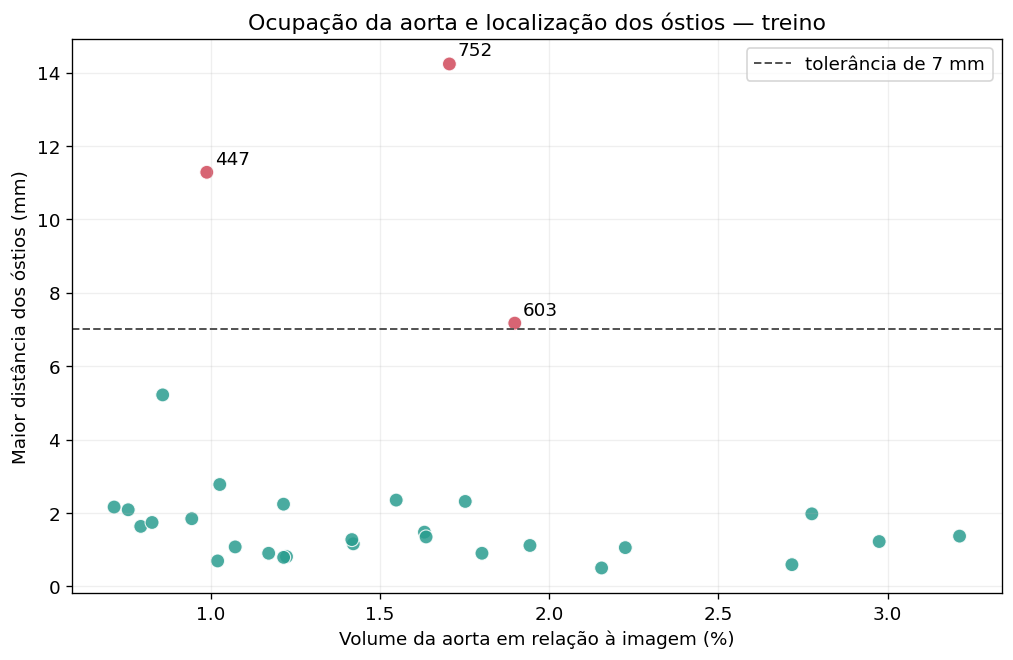

In [8]:
plot_ostia_relationship(train_df, "treino")

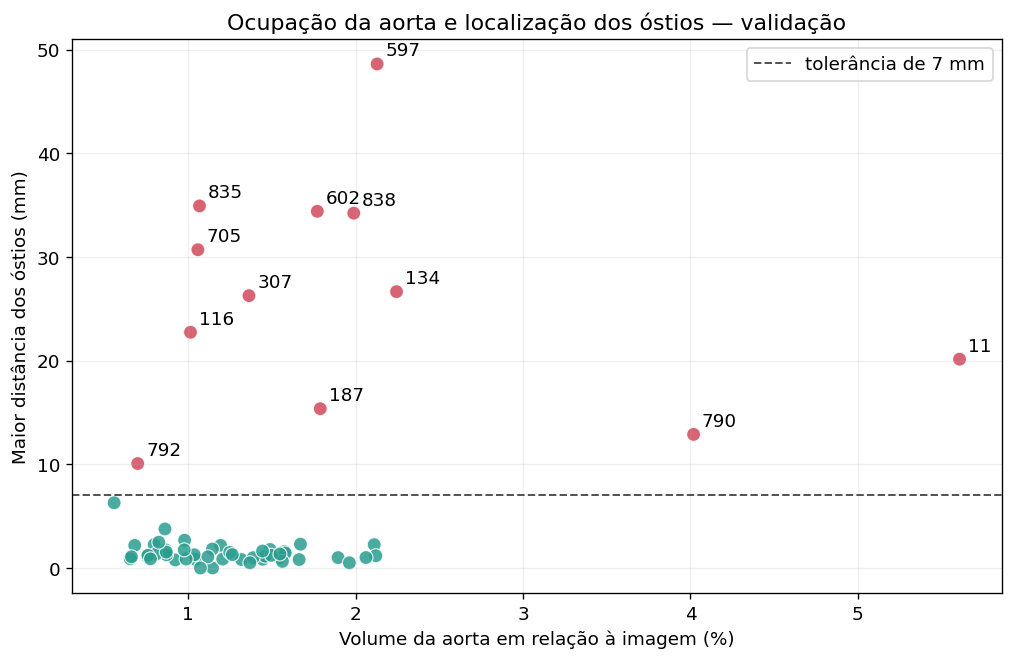

In [9]:
plot_ostia_relationship(val_df, "validação")

## 3. Qualidade visual da aorta

Cada subseção responde a uma pergunta específica e apresenta treino e validação em células consecutivas.

### 3.1. Qualidade visual versus desfecho dos óstios

In [10]:
print("Treino")
train_quality_vs_ostia = build_quality_crosstab(train_df)
display(train_quality_vs_ostia)

Treino


ostia_outcome,falha,sucesso,All
qualidade_visual_aorta,,,
boa,1,22,23
ruim,2,5,7
All,3,27,30


In [11]:
print("Validação")
val_quality_vs_ostia = build_quality_crosstab(val_df)
display(val_quality_vs_ostia)

Validação


ostia_outcome,falha,sucesso,All
qualidade_visual_aorta,,,
boa,4,43,47
ruim,8,5,13
All,12,48,60


### 3.2. Resumo por qualidade visual

In [12]:
print("Treino")
train_visual_summary = build_visual_summary(train_df)
display(train_visual_summary.round(3))

Treino


,visual_aorta_quality,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,voxels_por_fatia_mediana,volume_percentual_medio,volume_percentual_mediano,dice_arterial_medio
0,boa,23,228420.565,211046.0,118.348,1882.854,1701.984,1.317,1.215,0.622
1,ruim,7,362579.857,366834.0,118.857,3064.570,3182.310,2.334,2.225,0.591


In [13]:
print("Validação")
val_visual_summary = build_visual_summary(val_df)
display(val_visual_summary.round(3))

Validação


,visual_aorta_quality,imagens,voxels_aorta_media,voxels_aorta_mediana,fatias_segmentadas_media,voxels_por_fatia_media,voxels_por_fatia_mediana,volume_percentual_medio,volume_percentual_mediano,dice_arterial_medio
0,boa,47,195973.234,187388.0,111.149,1746.403,1758.691,1.167,1.117,0.619
1,ruim,13,375375.769,306716.0,130.846,2776.598,2824.057,2.204,1.989,0.369


### 3.3. Distribuição do volume e da área por fatia

Treino


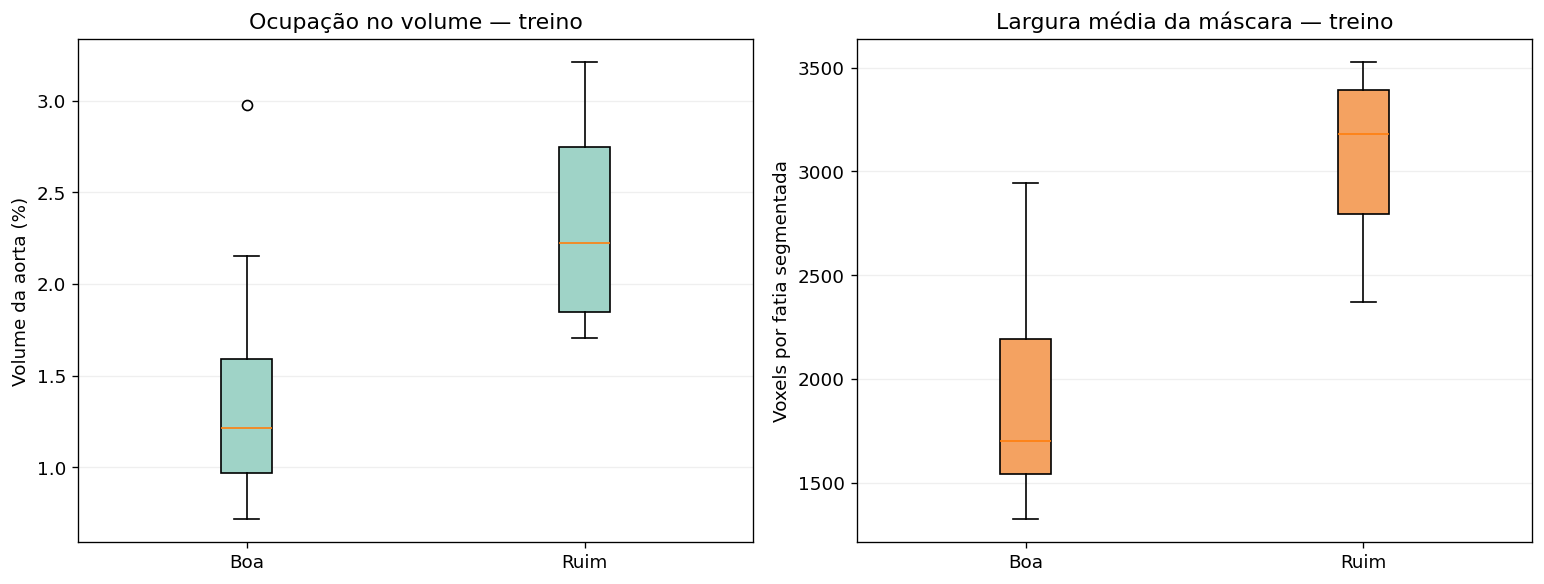

In [14]:
print("Treino")
plot_visual_quality(train_df, "treino")

Validação


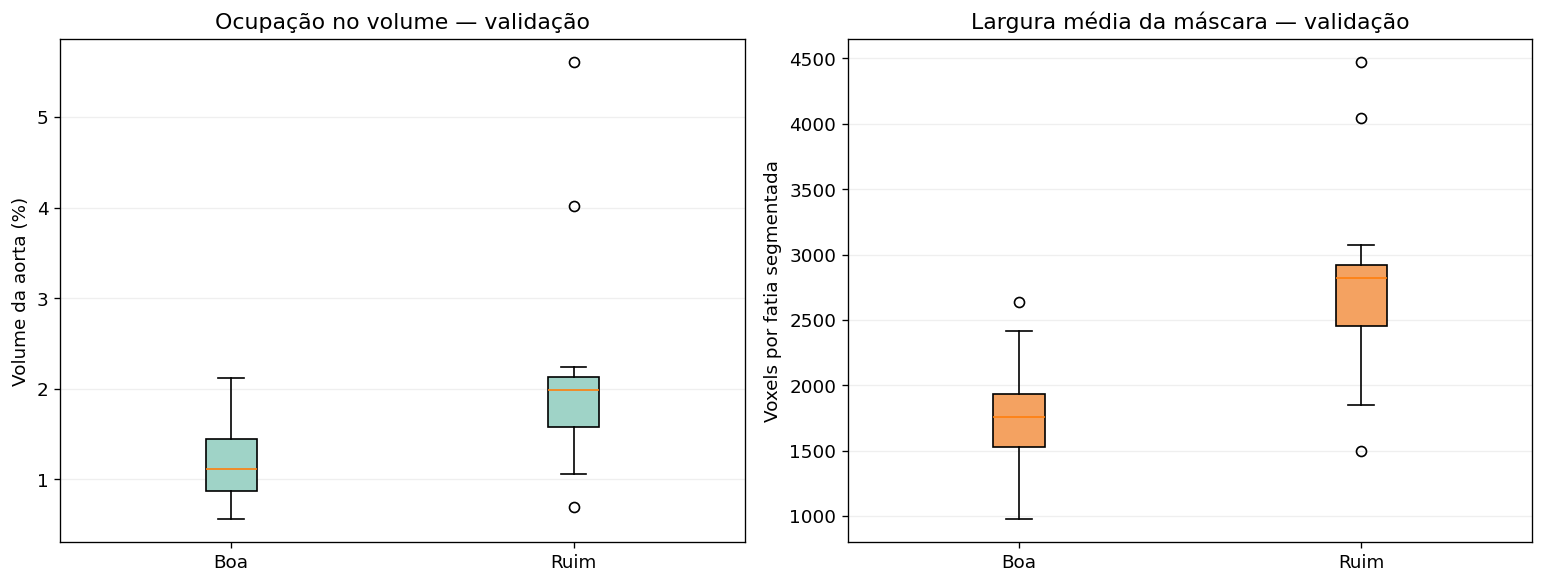

In [15]:
print("Validação")
plot_visual_quality(val_df, "validação")

### 3.4. Ocupação percentual por exame

Treino


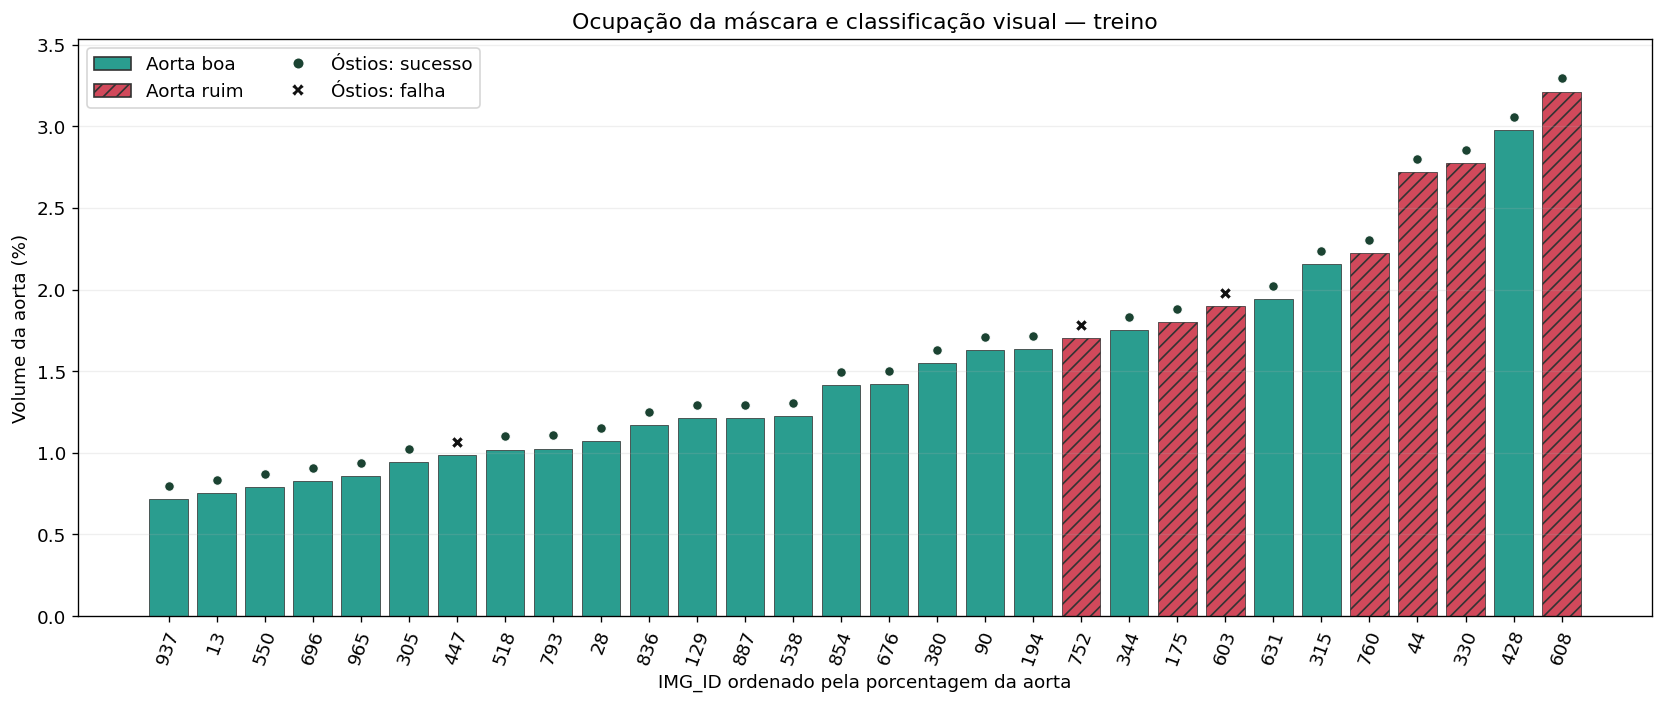

In [16]:
print("Treino")
plot_ordered_volume(train_df, "treino")

Validação


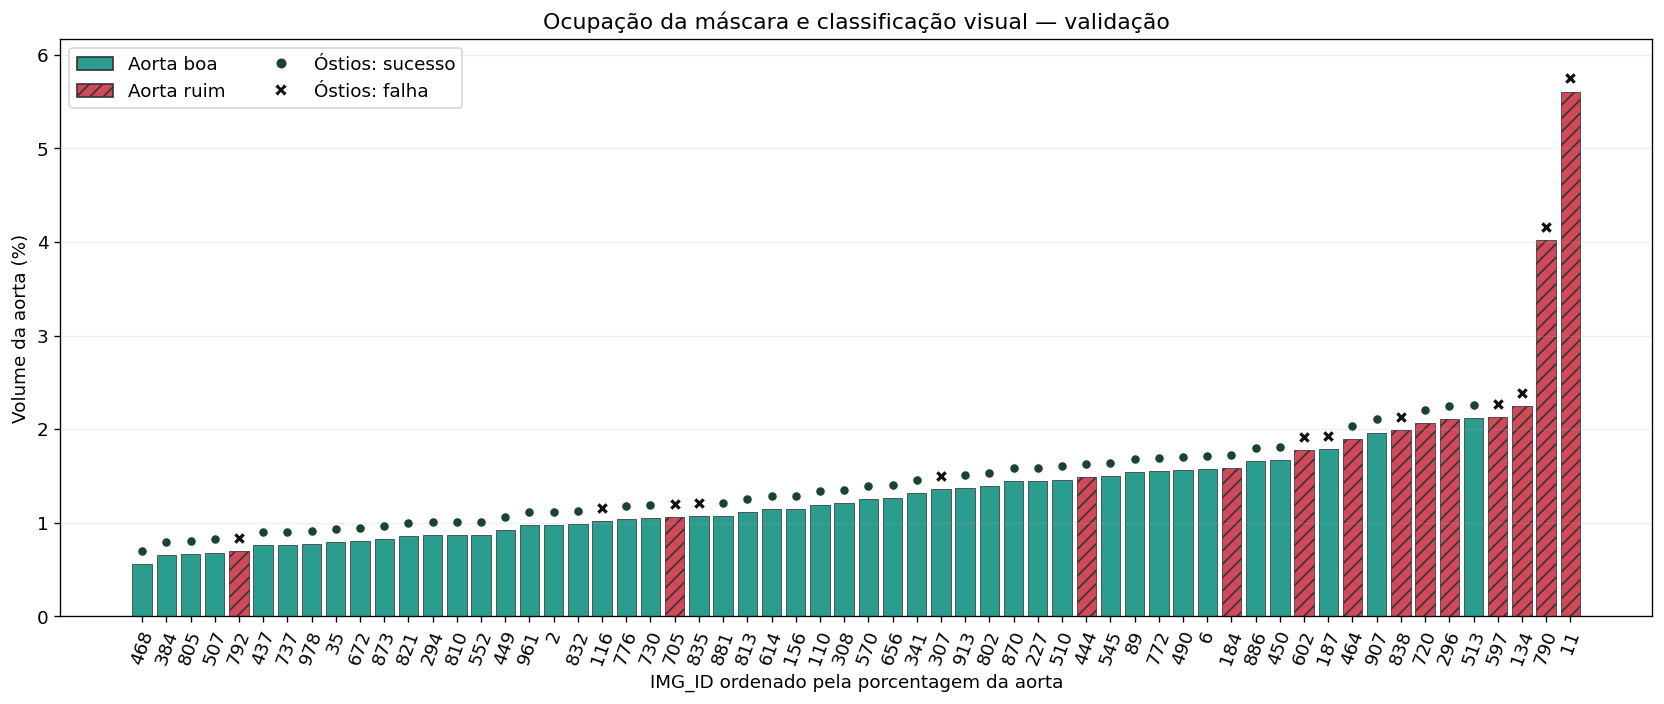

In [17]:
print("Validação")
plot_ordered_volume(val_df, "validação")

## 4. Faixa exploratória para triagem visual

O corte é ajustado somente no treino e aplicado sem recalibração na validação.

### 4.1. Desempenho do corte no treino e na validação

In [18]:
print("Treino")
train_threshold_df = find_volume_threshold(train_df)
train_best_threshold = float(
    train_threshold_df.iloc[0]["threshold_percentual"]
)
display(train_threshold_df.head(5).round(4))
print(f"Corte selecionado no treino: {train_best_threshold:.4f}%")

Treino


,threshold_percentual,acuracia,sensibilidade_aorta_ruim,especificidade_aorta_boa,acuracia_balanceada
18,1.6706,0.8667,1.0000,0.8261,0.9130
17,1.6337,0.8333,1.0000,0.7826,0.8913
16,1.5895,0.8000,1.0000,0.7391,0.8696
20,1.7766,0.8667,0.8571,0.8696,0.8634
15,1.4844,0.7667,1.0000,0.6957,0.8478


Corte selecionado no treino: 1.6706%


In [19]:
print("Validação")
val_threshold_evaluation = evaluate_volume_threshold(
    val_df,
    train_best_threshold,
)
display(val_threshold_evaluation.round(4))

Validação


,corte_do_treino_percentual,imagens,aortas_ruins_reais,aortas_sinalizadas,acuracia,sensibilidade_aorta_ruim,especificidade_aorta_boa,acuracia_balanceada
0,1.6706,60,13,12,0.8833,0.6923,0.9362,0.8142


## 5. Síntese comparativa

A tabela reúne os indicadores necessários para comparar aortas boas e ruins entre as duas coortes.

In [20]:
cohort_comparison = pd.concat(
    [
        train_df.assign(coorte="treino"),
        val_df.assign(coorte="validação"),
    ],
    ignore_index=True,
)
cohort_summary = (
    cohort_comparison.groupby(
        ["coorte", "visual_aorta_quality"], observed=True
    )
    .agg(
        imagens=("IMG_ID", "size"),
        sucesso_ostios=("ostia_success", "mean"),
        volume_percentual_medio=("aorta_volume_percentage", "mean"),
        volume_percentual_mediano=("aorta_volume_percentage", "median"),
        voxels_por_fatia_media=("aorta_voxels_per_segmented_slice", "mean"),
        dice_arterial_medio=("artery_dice", "mean"),
    )
    .reset_index()
)
display(cohort_summary.round(4))

,coorte,visual_aorta_quality,imagens,sucesso_ostios,volume_percentual_medio,volume_percentual_mediano,voxels_por_fatia_media,dice_arterial_medio
0,treino,boa,23,0.9565,1.3174,1.2149,1882.8538,0.6221
1,treino,ruim,7,0.7143,2.3336,2.2248,3064.5699,0.5908
2,validação,boa,47,0.9149,1.1670,1.1169,1746.4027,0.6193
3,validação,ruim,13,0.3846,2.2037,1.9886,2776.5976,0.3687


## Conclusão

A organização por métrica permite comparar treino e validação imediatamente. A seção redundante de aortas confirmadas foi removida, pois seus indicadores já estão disponíveis no resumo por qualidade visual e no cruzamento com o desfecho dos óstios.

In [21]:
train_good = train_df.loc[train_df["visual_aorta_quality"].eq("boa")]
train_bad = train_df.loc[train_df["visual_aorta_quality"].eq("ruim")]
val_good = val_df.loc[val_df["visual_aorta_quality"].eq("boa")]
val_bad = val_df.loc[val_df["visual_aorta_quality"].eq("ruim")]

print("Síntese da análise:")
print(
    f"- Treino: {len(train_good)}/{len(train_df)} aortas boas "
    f"({len(train_good) / len(train_df):.1%})."
)
print(
    f"- Validação: {len(val_good)}/{len(val_df)} aortas boas "
    f"({len(val_good) / len(val_df):.1%})."
)
print(
    f"- Volume médio treino — boas: {train_good['aorta_volume_percentage'].mean():.2f}%; "
    f"ruins: {train_bad['aorta_volume_percentage'].mean():.2f}%."
)
print(
    f"- Volume médio validação — boas: {val_good['aorta_volume_percentage'].mean():.2f}%; "
    f"ruins: {val_bad['aorta_volume_percentage'].mean():.2f}%."
)
print(
    f"- Corte aprendido no treino: {train_best_threshold:.2f}%; "
    f"acurácia balanceada na validação: "
    f"{val_threshold_evaluation.iloc[0]['acuracia_balanceada']:.1%}."
)
print(
    f"- Sucesso dos óstios nas aortas boas da validação: "
    f"{val_good['ostia_success'].mean():.1%}."
)
print("- O exame 821 foi mantido como bom, com ressalva de que poderia ser segmentado um pouco mais.")

Síntese da análise:
- Treino: 23/30 aortas boas (76.7%).
- Validação: 47/60 aortas boas (78.3%).
- Volume médio treino — boas: 1.32%; ruins: 2.33%.
- Volume médio validação — boas: 1.17%; ruins: 2.20%.
- Corte aprendido no treino: 1.67%; acurácia balanceada na validação: 81.4%.
- Sucesso dos óstios nas aortas boas da validação: 91.5%.
- O exame 821 foi mantido como bom, com ressalva de que poderia ser segmentado um pouco mais.
